## Figure 7 (a),(b) — stability-region shape at two extreme overlaps
---

Class III Rössler system (couple $x$), $N=100$, $k^{(1)}=6$, $k^{(2)}=3$. Panel (a): $\{\mathcal T^{(2)},\mathcal I^{(1,2)}\}=\{0,1\}$; panel (b): $\{1,1\}$. Each is the synchronization-stability region (black) in the $(\sigma_1,\sigma_2)$ plane, obtained by the **same numerical sweep as Fig. 3(d)**.

The paper's point: with **minimal** intra overlap (a) the region is a finite class-III band even at $\sigma_1\to0$; with **maximal** intra overlap (b) the triangle set is disconnected, so as $\sigma_1\to0$ synchronization is impossible — the left boundary becomes vertical (class-I-like).

> **Same runtime caveat as Fig. 3:** these are full Rössler integrations (`h=1e-3`, ~1.5M steps/cell). Use the `coarse` preset first; the `paper` preset needs numba. `util.rossler_error_grid(...coupling="type3")` is reused.


In [1]:
import sys, os, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.insert(0, os.getcwd())
import util
sys.path.insert(0, util.OVERLAP_DIR)
from hyperedge_overlap_utils import (intra_order_hyperedge_overlap as intra_overlap,
                                      inter_order_hyperedge_overlap as inter_overlap)
out_dir = Path(util.REPO_ROOT) / 'outputs' / 'fig7'
out_dir.mkdir(parents=True, exist_ok=True)
rng_seed = 1

In [2]:
def structure_at_overlap(N, k1, k2, target_T2, target_I12, seed=0):
    '''Approximate generator spanning (T2, I12) in [0,1]^2 for M=2.

    Strategy:
      * Triangles: interpolate between clustered blocks (T2~1) and random
        regular (T2~0) by assigning a fraction ~target_T2 of nodes to blocks.
      * Pairs: a fraction ~target_I12 of the required triangle-faces are added
        as links (raising inter-order overlap); the remaining links are random
        to keep k1 regular-ish.
    Returns pairs, triangles.
    '''
    rng = np.random.default_rng(seed)
    # ---- triangles: blend blocked and random ----
    # blocks of size 4 give k2 = C(3,2) = 3
    Bsz = util.block_size_for_degrees({2: k2})   # k2=3 -> B=4
    n_block_nodes = int(round(target_T2 * N))
    n_block_nodes -= n_block_nodes % Bsz         # multiple of block size
    tri_list = []
    if n_block_nodes >= Bsz:
        blk, _ = util.clustered_blocks(n_block_nodes, Bsz, orders=[2], seed=seed)
        tri_list.append(blk[2])
    # remaining nodes get random-regular triangles
    rem = np.arange(n_block_nodes, N)
    if len(rem) >= 3:
        rt, _ = util.random_regular_mbody(len(rem), k2, 2, seed=seed+1)
        tri_list.append(rt + n_block_nodes)
    triangles = np.vstack([t for t in tri_list if len(t)]) if tri_list else \
                util.random_regular_mbody(N, k2, 2, seed=seed)[0]
    # ---- pairs: mix triangle-faces (inter overlap) with random links ----
    faces = set()
    for a,b,c in triangles:
        faces.add(tuple(sorted((a,b)))); faces.add(tuple(sorted((a,c)))); faces.add(tuple(sorted((b,c))))
    faces = list(faces); rng.shuffle(faces)
    n_face_links = int(round(target_I12 * len(faces)))
    chosen = set(faces[:n_face_links])
    # top up with random links to approx k1-regular
    deg = np.zeros(N,int)
    pairs = set(chosen)
    for a,b in chosen: deg[a]+=1; deg[b]+=1
    target_links = k1*N//2
    tries=0
    while len(pairs) < target_links and tries < 200000:
        tries+=1
        i,j = rng.integers(0,N,2)
        if i==j: continue
        e=tuple(sorted((int(i),int(j))))
        if e in pairs: continue
        pairs.add(e); deg[i]+=1; deg[j]+=1
    return np.array(sorted(pairs),dtype=np.int64), triangles

# quick single-point sanity
p,t = structure_at_overlap(100,6,3,0.5,0.5,seed=0)
print("sanity:", intra_overlap(t,2)[0], inter_overlap(p,1,t,2))

sanity: 0.5 0.5111111111111111


In [3]:
PRESET7 = "medium"   # "coarse" | "paper"
CFG7 = {"coarse": dict(n_steps=300, grid=13, n_resampling=100),
        "medium": dict(n_steps=400, grid=15, n_resampling=100),
        "paper":  dict(n_steps=1500, grid=25, n_resampling=200)}[PRESET7]
N=100; k1=6; k2=3
s1_7 = np.logspace(-6,0,CFG7["grid"]); s2_7 = np.logspace(-6,0,CFG7["grid"])

# (a) T2=0, I12=1  : random-ish triangles (connected), pairs = triangle faces
pa, ta = structure_at_overlap(N,k1,k2, target_T2=0.0, target_I12=1.0, seed=0)
# (b) T2=1, I12=1  : blocked triangles (disconnected), pairs include faces
pb, tb = structure_at_overlap(N,k1,k2, target_T2=1.0, target_I12=1.0, seed=0)
for tag,p,t in [("(a){0,1}",pa,ta),("(b){1,1}",pb,tb)]:
    print(tag,"T2=%.2f I12=%.2f"%(intra_overlap(t,2)[0], inter_overlap(p,1,t,2)))
    # connectedness of triangle layer:
    L2,_=util._laplacian_fixed_N(t,2,N); w=np.sort(np.linalg.eigvalsh((L2+L2.T)/2))
    print("     triangle-layer lambda2=%.3f (0 => disconnected)"%w[1])

(a){0,1} T2=0.03 I12=1.00
     triangle-layer lambda2=1.076 (0 => disconnected)
(b){1,1} T2=1.00 I12=1.00
     triangle-layer lambda2=-0.000 (0 => disconnected)


In [11]:
## DO NOT RUN
def run_region(pairs, triangles, tag):
    ln,_ = util.neighbors_from_pairs(pairs, N)
    t0=time.time()
    err,_ = util.rossler_error_grid(N, ln, triangles, s1_7, s2_7,
        h=1e-3, n_steps=CFG7["n_steps"], n_resampling=CFG7["n_resampling"],
        coupling="type3", seed=0, verbose=False)
    print(f"{tag} done in {time.time()-t0:.1f}s")
    return err

err_a = run_region(pa, ta, "panel(a)")
err_b = run_region(pb, tb, "panel(b)")

# save
np.save(out_dir / 'fig7-a.npy', err_a)
np.save(out_dir / 'fig7-b.npy', err_b)

panel(a) done in 775.2s
panel(b) done in 754.1s


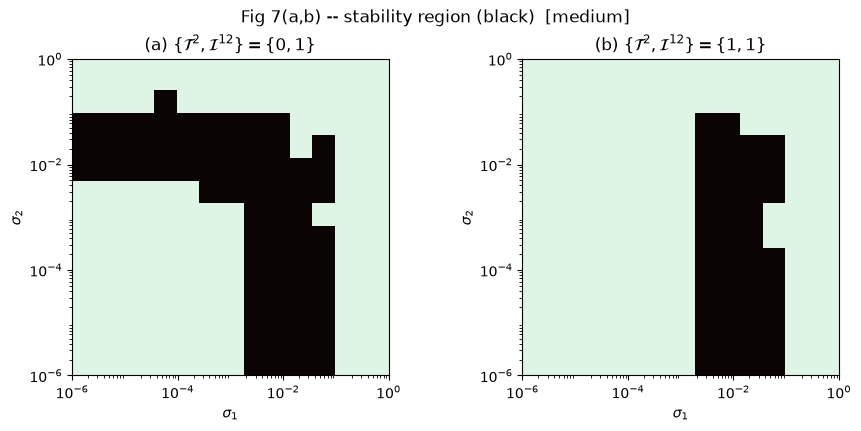

In [4]:
# load
err_a = np.load(out_dir / 'fig7-a.npy')
err_b = np.load(out_dir / 'fig7-b.npy')

# Binarize into stability region (black = synchronized = small error)
thr = 1.0   # error threshold defining "synchronized"
fig, axes = plt.subplots(1,2, figsize=(9,4.2), constrained_layout=True)
for ax, err, ttl in zip(axes, [err_a, err_b],
                        [r"(a) $\{\mathcal{T}^2,\mathcal{I}^{12}\}=\{0,1\}$",
                         r"(b) $\{\mathcal{T}^2,\mathcal{I}^{12}\}=\{1,1\}$"]):
    region = (err < thr).astype(float)
    ax.pcolormesh(s1_7, s2_7, region, shading="auto", cmap=plt.colormaps['mako_r'])
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$\sigma_1$")
    ax.set_ylabel(r"$\sigma_2$")
    ax.set_title(ttl)
    ax.set_box_aspect(1)
    ax.set_xlim([1e-6, 1])
    ax.set_ylim([1e-6, 1])
    ax.set_xticks([1, 1e-2, 1e-4, 1e-6])
    ax.set_yticks([1, 1e-2, 1e-4, 1e-6])
fig.suptitle(f"Fig 7(a,b) -- stability region (black)  [{PRESET7}]")
plt.show()

fig.savefig("figures/Fig7.png", dpi=300, bbox_inches="tight")